In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

In [2]:
file_path = "../data/raw/Crop_recommendation.csv"
df_soil = pd.read_csv(file_path)
df_soil.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print("=== PROVENIENȚĂ DATE ȘI ANALIZĂ VALORI LIPSE ===")
print("Sursa primară a datelor: Kaggle Crop Recommendation Benchmark Dataset")
print(f"Volum total date brute: {len(df_soil)} rânduri")
valori_lipsa = df_soil.isnull().sum()
print("\nNumărul de valori lipsă (Missing Values) per caracteristică:")
print(valori_lipsa)
print("\nStrategia de producție: Pipeline-ul va integra un bloc 'SimpleImputer(strategy='median')'")
print("pentru a substitui automat eventualele pachete de date pierdute de senzorii IoT din teren.")

=== PROVENIENȚĂ DATE ȘI ANALIZĂ VALORI LIPSE ===
Sursa primară a datelor: Kaggle Crop Recommendation Benchmark Dataset
Volum total date brute: 2200 rânduri

Numărul de valori lipsă (Missing Values) per caracteristică:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Strategia de producție: Pipeline-ul va integra un bloc 'SimpleImputer(strategy='median')'
pentru a substitui automat eventualele pachete de date pierdute de senzorii IoT din teren.


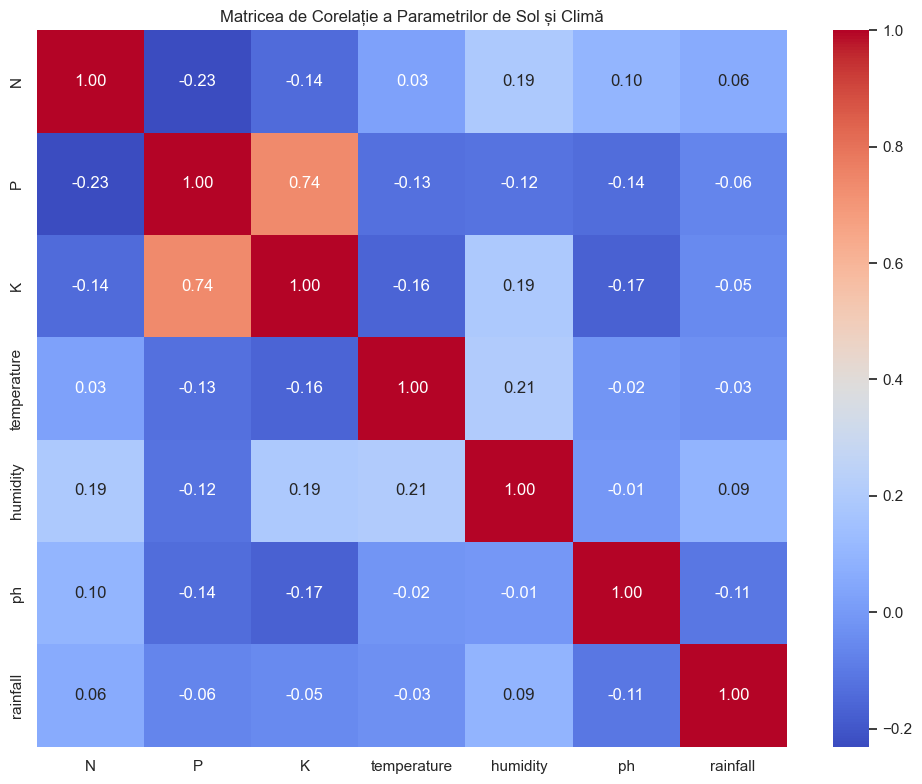

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_soil.drop('label', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matricea de Corelație a Parametrilor de Sol și Climă')
plt.tight_layout()
plt.show()

C:\Users\nicol\AppData\Local\Temp\ipykernel_6036\1738008187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df_soil, order=df_soil['label'].value_counts().index, palette='viridis')


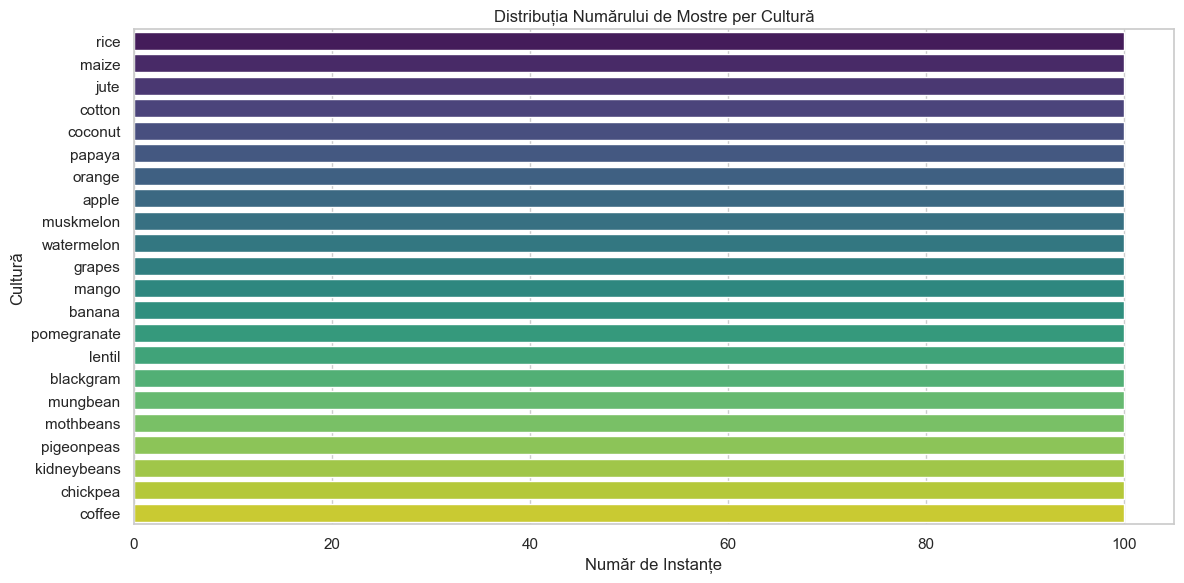

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(y='label', data=df_soil, order=df_soil['label'].value_counts().index, palette='viridis')
plt.title('Distribuția Numărului de Mostre per Cultură')
plt.xlabel('Număr de Instanțe')
plt.ylabel('Cultură')
plt.tight_layout()
plt.show()

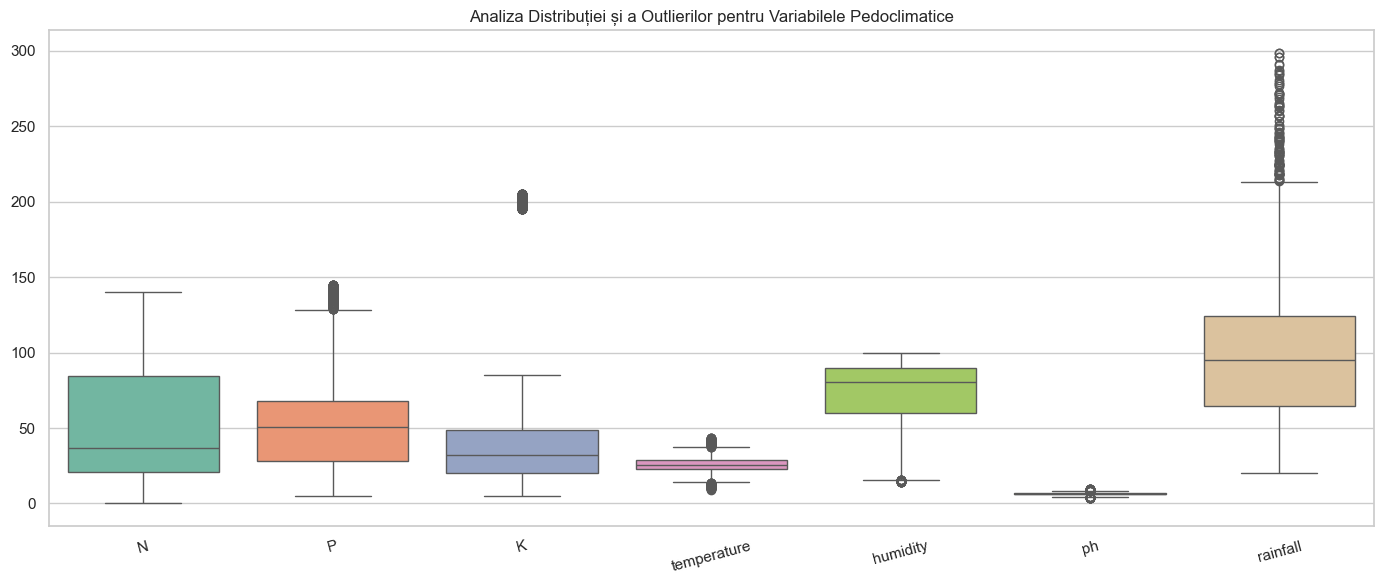

In [6]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_soil.drop('label', axis=1), palette='Set2')
plt.title('Analiza Distribuției și a Outlierilor pentru Variabilele Pedoclimatice')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [7]:
print("=== ANALIZĂ ETICĂ ȘI LIMITĂRI PEDOCLIMATICE LOCALE (REPUBLICA MOLDOVA) ===")
print("1. Datasetul utilizat reprezintă o bază idealizată/sintetică de calibrare globală.")
print("2. Solurile din Republica Moldova sunt majoritar cernoziomuri cu conținut ridicat de humus, ale căror particularități includ un deficit de Fosfor (P) mobil.")
print("3. Factorii macro-climatici locali (vulnerabilitate la secetă în Sud) decuplează comportamentul real de datele ideale.")
print("4. Strategie Zero-API: Pentru funcționare stabilă pe câmp fără internet, sistemul este 100% autonom. Datele sunt colectate direct de senzori locali, fără interogări către API-uri externe.")

=== ANALIZĂ ETICĂ ȘI LIMITĂRI PEDOCLIMATICE LOCALE (REPUBLICA MOLDOVA) ===
1. Datasetul utilizat reprezintă o bază idealizată/sintetică de calibrare globală.
2. Solurile din Republica Moldova sunt majoritar cernoziomuri cu conținut ridicat de humus, ale căror particularități includ un deficit de Fosfor (P) mobil.
3. Factorii macro-climatici locali (vulnerabilitate la secetă în Sud) decuplează comportamentul real de datele ideale.
4. Strategie Zero-API: Pentru funcționare stabilă pe câmp fără internet, sistemul este 100% autonom. Datele sunt colectate direct de senzori locali, fără interogări către API-uri externe.
